# Lab 0: Choosing A Dataset, Understanding it and First Checks

Before I could do any analysis, I needed to actually look at the data. Not just load it into pandas and assume it's fine — really look at it. How many rows? How many columns? Are the column names the same across all five yearly files? Where are the missing values hiding?
This is the lab where I figured out the shape of the problem I'd be working on for the rest of the semester.

## Loading and normalizing the data files — fixing the schema inconsistencies

To start, I needed to load all five CSVs from the raw data folder, infer the year from each filename, and merge them into one combined dataframe. Before I could do that, I noticed that column names aren't consistent across years (e.g., 'Economy (GDP per Capita)' vs 'GDP per capita'). That kind of inconsistency will silently cause NaN floods if you try to merge without normalizing — so I built a mapping to standardize the schema.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("..") / ".." / "data" / "raw"
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_PATH = CACHE_DIR / "lab0_all_years.csv"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

COLUMN_MAP = {
    "Country": "country",
    "Country or region": "country",
    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",
    "Trust (Government Corruption)": "trust",
    "Trust..Government.Corruption.": "trust",
    "Perceptions of corruption": "trust",
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",
    "Health (Life Expectancy)": "life_expectancy",
    "Health..Life.Expectancy.": "life_expectancy",
    "Healthy life expectancy": "life_expectancy",
    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",
    "Family": "social_support",
    "Social support": "social_support",
    "Generosity": "generosity"
}

def infer_year_from_filename(name: str) -> int | None:
    match = re.search(r"(19|20)\d{2}", name)
    return int(match.group()) if match else None

def load_all_years(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()}")

    frames = []
    for fp in files:
        df = pd.read_csv(fp)
        df["year"] = infer_year_from_filename(fp.name)
        df = df.rename(columns={c: COLUMN_MAP.get(c, c) for c in df.columns})
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    return full

if CACHE_PATH.exists():
    df = pd.read_csv(CACHE_PATH)
else:
    df = load_all_years(DATA_DIR)
    df.to_csv(CACHE_PATH, index=False)

df.head()

,country,Region,Happiness Rank,happiness_score,Standard Error,gdp_per_capita,social_support,life_expectancy,freedom,trust,generosity,Dystopia Residual,year,Lower Confidence Interval,Upper Confidence Interval,Happiness.Rank,Whisker.high,Whisker.low,Dystopia.Residual,Overall rank
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking for country name inconsistencies across years


In [ ]:
name_counts = df.groupby("country")["year"].nunique()
appears_all = name_counts[name_counts == 5]
appears_partial = name_counts[name_counts < 5]
print(f"Countries appearing all 5 years: {len(appears_all)}")
print(f"Countries with incomplete coverage: {len(appears_partial)}")
print(appears_partial.sort_values())

Observation: Flag any countries with inconsistent spellings (e.g., "Hong Kong S.A.R., China" vs "Hong Kong") that would appear as separate entries in the groupby.


## Building a column overview table — finding the missing values

Once merged, I created a column overview table documenting each column's name, data type, and missing percentage. I needed to see exactly what features were fully populated and which ones were missing data so I could decide how to clean them later.

In [2]:
overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
})
overview

,column,dtype,missing_pct
0,country,str,0.00
1,Region,str,59.72
2,Happiness Rank,float64,59.72
3,happiness_score,float64,0.00
4,Standard Error,float64,79.80
5,gdp_per_capita,float64,0.00
6,social_support,float64,0.00
7,life_expectancy,float64,0.00
8,freedom,float64,0.00
9,trust,float64,0.13


**Observation:**
Looking at the overview table, I found that the total number of rows across all years is 856. The six core predictor columns — GDP, social support, life expectancy, freedom, generosity, trust — are almost fully populated with missing percentages at or near 0%. That was a relief. The problem column is `Region`, which has nearly 60% missing data because it exists in 2015 and 2016 but not in the later years. The report changed its format, and no one added it back.

## Persisting the overview table

I'm saving this overview table to a CSV file. This acts as a reference document for the data's raw state, which will be useful for auditing and deciding on imputation strategies in the upcoming labs.

In [3]:
overview.to_csv(TABLES_DIR / "lab0_column_overview.csv", index=False)

## Visualizing missing values — seeing the gaps

To make the missing data easier to digest, I created a bar plot of the missing percentages. A visual representation helps immediately highlight which features are unusable and which are safe to rely on for modeling.

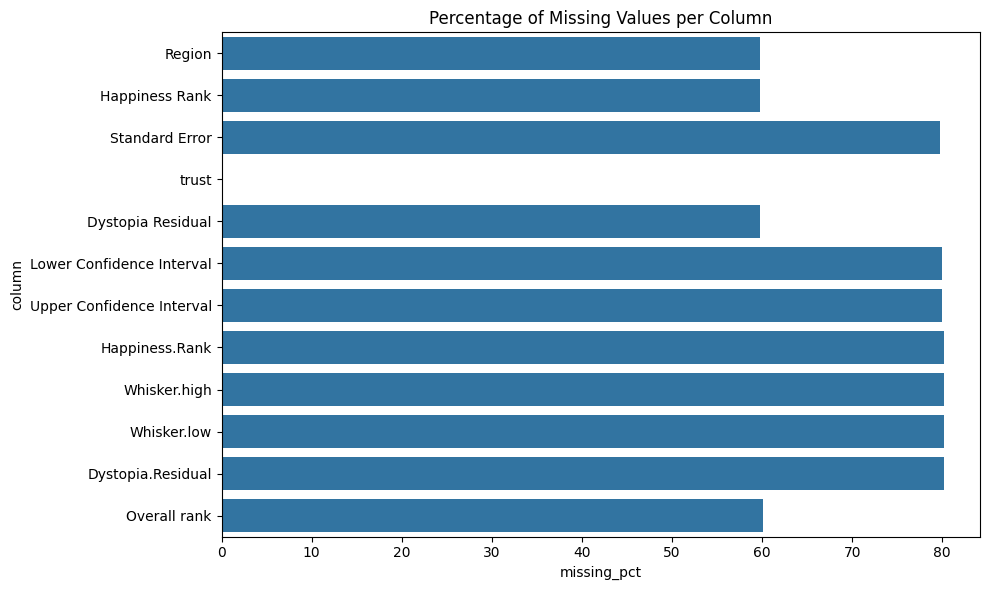

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(x="missing_pct", y="column", data=overview[overview["missing_pct"] > 0])
plt.title("Percentage of Missing Values per Column")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab0_plot_missing_values.png", dpi=300)
plt.show()

## Checking the happiness score distribution — understanding the target variable

Finally, I plotted the distribution of the target variable, `happiness_score`. I needed to know if it's normally distributed, skewed, or has any strange outliers before trying to fit a regression model to it.

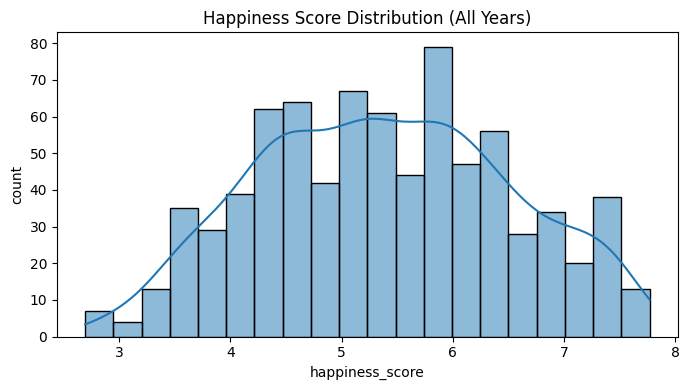

In [5]:
if "happiness_score" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df["happiness_score"].dropna(), bins=20, kde=True)
    plt.title("Happiness Score Distribution (All Years)")
    plt.xlabel("happiness_score")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "lab0_plot_happiness_distribution.png", dpi=300)
    plt.show()

**Observation:**
I found that the happiness score distribution is roughly bell-shaped, centered around 5.4, with a small left skew. No country scores above 7.8 or below 2.8. What surprised me is that the dataset is smaller than I expected — 856 rows for a five-year global study is genuinely not a lot. That will matter when I get to modeling, as I'll need to be careful not to overfit.

## What Comes Next

The most important finding from this lab is that the six core predictors are well-populated and the target variable is reasonably well-behaved, meaning the dataset is trustworthy enough to build on. Lab 1 takes one of these columns — trust — and asks whether it has a real quantitative relationship with happiness.